In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , accuracy_score

In [9]:
from sklearn.metrics import (confusion_matrix, mean_squared_error,classification_report ,
roc_curve , roc_auc_score,mean_absolute_error)
import matplotlib.pyplot as plt

In [10]:
import numpy as np

In [11]:
df = pd.read_csv('student-mat.csv')

In [12]:
print (df.shape , df.dtypes)

(395, 33) school                        str
sex                           str
age                         int64
address                       str
famsize                       str
Parrent_status                str
Mother_edu                  int64
Father_edu                  int64
Mother_job                    str
Father_job                    str
reason_to_chose_school        str
guardian                      str
traveltime                  int64
weekly_studytime            int64
failures                    int64
extra_edu_supp                str
family_edu_supp               str
extra_paid_class              str
extra_curr_activities         str
nursery                       str
Interested_in_higher_edu      str
internet_access               str
romantic_relationship         str
Family_quality_reln         int64
freetime_after_school       int64
goout_with_friends          int64
workday_alcohol_consum      int64
weekend_alcohol_consum      int64
health_status               int64
abse

In [30]:
print(df["internet_access"])

0       no
1      yes
2      yes
3      yes
4       no
      ... 
390     no
391    yes
392     no
393    yes
394    yes
Name: internet_access, Length: 395, dtype: str


In [50]:
#Qual a relação entre um bom aluno no G1 continuar sendo um bom aluno no G3?
# Calculo de regressão linear
x_train, x_test,y_train,y_test = train_test_split(
    df[["G1","G2"]],df[["G3"]],test_size=0.2,random_state=42)


In [51]:
# Treinamento
model_lreg = LinearRegression()

model_lreg.fit(x_train,y_train)

y_reg_pred = model_lreg.predict(x_test)


In [56]:
# Metricas
rmse = np.sqrt(mean_squared_error(x_test["G1"],y_reg_pred))
mae = mean_absolute_error(x_test["G1"],y_reg_pred)
R2_score = model_lreg.score(x_test,y_test) 


print(f"Root Mean Squared Error: {rmse:.2f}") # O quão longe uma previsão esta do valor real, dependendo da unidade de medida
print(f"R2 Score: {R2_score:.4f}") # r^2

# Representão os valores da função linear | y = ax + b |
print(f"Coeficiente angular: {model_lreg.coef_}")
print(f"Coeficiente linear: {model_lreg.intercept_}")


Root Mean Squared Error: 1.46
R2 Score: 0.7946
Coeficiente angular: [[0.16313828 0.99318622]]
Coeficiente linear: [-2.03704928]


In [65]:
df_plot = pd.DataFrame({'x': x_test["G1"], 'y': y_reg_pred})
df_plot = df_plot.sort_values(by='x')

x_plot = x_test["G1"]
# Grafico da regressão linear
plt.scatter(x_test["G1"], y_test, color='blue', label='Dados Reais')
plt.plot(df_plot['x'], df_plot['y'], color='red', linewidth=3, label='Reta de Regressão')
plt.xlabel('Variável Independente')
plt.ylabel('Target')
plt.legend()
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

In [41]:
x_train_log, x_test_log,y_train_log,y_test_log = train_test_split(
    df[["G1","G2","G3"]],df[["internet_access"]],test_size=0.2,random_state=42)


y_train_log = pd.get_dummies(y_train_log,drop_first=True)
y_test_log = pd.get_dummies(y_test_log,drop_first=True)


log = LogisticRegression(max_iter =5000)

log.fit(x_train_log , y_train_log)

prob = log.predict_proba(x_test_log)[:, 1]

print(f"AUC = {roc_auc_score(y_test_log , prob):.4f}") # Mede o quão bom é um modelo de 0.5 a 1



AUC = 0.5510


c:\Users\william\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


c:\Users\william\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


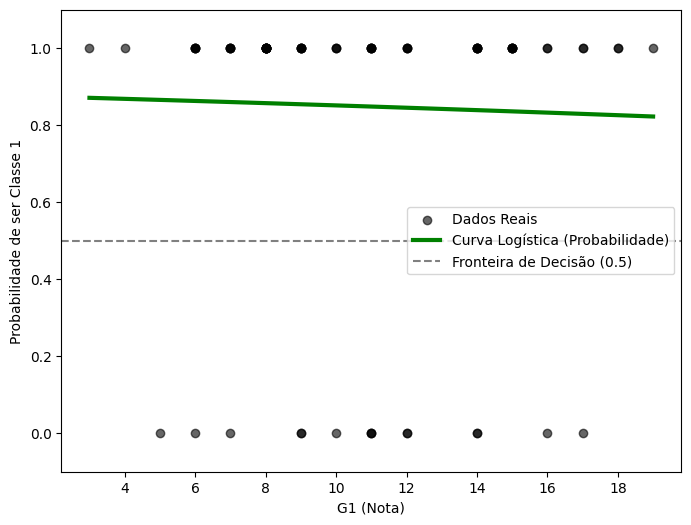

In [ ]:

x_range  =   np.linspace(x_test_log['G1'].min(), x_test_log['G1'].max(), 100)

# Gerando pontos para a curva logística
pontos_de_curva = np.column_stack([
    x_range,
    np.full_like(x_range, x_test_log['G2'].mean()), 
    np.full_like(x_range, x_test_log['G3'].mean())
])
prob_curva = log.predict_proba(pontos_de_curva)[:, 1]

# Plotando
plt.figure(figsize=(8, 6))
plt.scatter(x_test_log["G1"], y_test_log, color='black', zorder=20, label='Dados Reais', alpha=0.6)
plt.ylim(-0.1, 1.1) # Isso faz a curva "aparecer" e não ficar achatada no fundo
plt.plot(x_range, prob_curva, color='green', linewidth=3, label='Curva Logística (Probabilidade)')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Fronteira de Decisão (0.5)')
plt.ylabel('Probabilidade de ter acesso à Internet')
plt.xlabel('G1 (Nota)')
plt.legend()
plt.show()

--- Threshold = 0.3 ---
[[ 0 15]
 [ 0 64]]
--- Threshold = 0.5 ---
[[ 0 15]
 [ 0 64]]
--- Threshold = 0.7 ---
[[ 0 15]
 [ 1 63]]


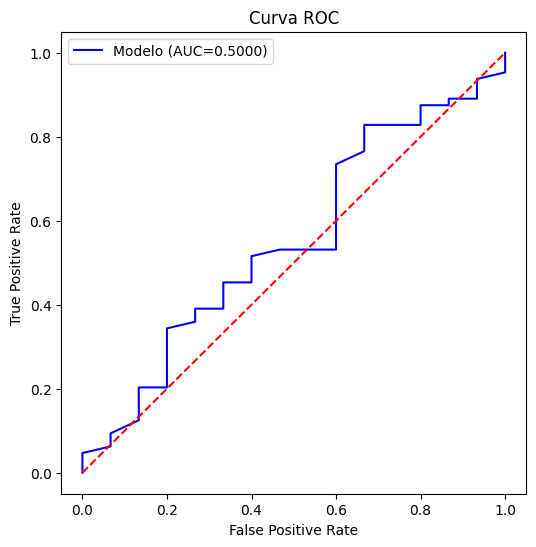

In [46]:

for th in [0.3,0.5,0.7]:
    pred_th = (prob >= th).astype(int)
    print(f"--- Threshold = {th} ---")
    print(confusion_matrix(y_test_log , pred_th))

fpr,tpr,ths = roc_curve(y_test_log , prob)
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,"b-",label=f"Modelo (AUC={roc_auc_score(y_test_log , (prob >= 0.5).astype(int)):.4f})")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

